<p>
<img src="https://drive.google.com/uc?id=1ZHUKcwzA5c-PKUwoGmBG3TsHk6TmZ-Y0" align="left" width="100">
</p>
<h3></h3>
<h3><b><center>Mecánica Celeste, Jorge I. Zuluaga</center></b></h3>
<h4><b><center>Quiz 5, Propiedades del CRTBP, simetrías y el Hamiltoniano</center></b><h4>
<h4><b><center>Punto Extra</center></b><h4>
</center>
</p>

<hr/>
<b>Cédula</b>: 1000534026
<hr/>

## Trompo

El Lagrangiano de un trompo de masa $M=1$ kg, con momentos de inercia principal $I_1=0.0125$ kg m$^2$ y secundario $I_3=0.005$ kg m$^2$ y en el cuál el centro de gravedad está a una distancia $l=10$ cm del punto de apoyo, es:

$$
L=\frac{I_1}{2}\left(\dot{\theta}^2+\dot{\phi}^2 \sin ^2 \theta\right)+\frac{I_3}{2}(\dot{\psi}+\dot{\phi} \cos \theta)^2-M g l \cos \theta
$$

Resuelva numéricamente, haga un gráfico de los ángulos como función del tiempo y estime (a partir de la gráfica) el tiempo que le toma al trompo precesar 360 grados alrededor del eje vertical cuando se usan como condiciones iniciales: $\theta=30^\circ$, $\phi=\psi=0^\circ$, $d{\theta}/dt=0$, ${d\psi}{/dt}=100$ rad/s y $d\phi/dt=0.01$ rad/s.

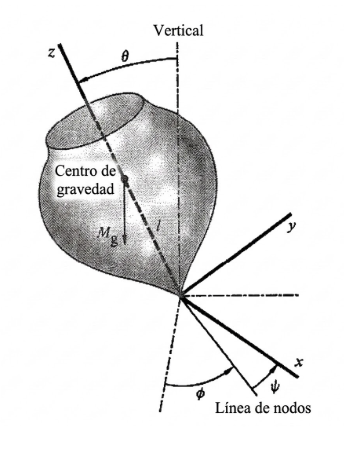

In [2]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [19]:
# Parámetros del sistema

I1 = 0.0125    # Momento de inercia transversal
I3 = 0.005      # Momento de inercia axial (trompo achatado)
M = 1.0       # Masa
g = 9.81      # Gravedad
l = 10       # Distancia del punto fijo al centro de masa

# Condiciones iniciales

theta0 = 30*np.pi/180   # Inclinación inicial
phi0 = 0.0           # Precesión inicial
psi0 = 0.0           # Rotación propia inicial
theta_dot0 = 0.0     # Soltado desde el reposo en nutación
phi_dot0 = 0.01       # Sin precesión inicial
psi_dot0 = 100.0      # ¡Alta velocidad de rotación propia!

# Constantes de movimiento (a y b)
# Usamos las definiciones de Goldstein (Ecs. 5.53 y 5.54)
# p_psi = I3 * (psi_dot + phi_dot * cos(theta)) = I1 * a
a = (I3 / I1) * (psi_dot0 + phi_dot0 * np.cos(theta0))

# p_phi = (I1 * sin^2(theta) + I3 * cos^2(theta)) * phi_dot + I3 * cos(theta) * psi_dot = I1 * b
b = (np.sin(theta0)**2) * phi_dot0 + (I3 / I1) * np.cos(theta0) * (psi_dot0 + phi_dot0 * np.cos(theta0))


# Sistemas de ecuaciones (Reducción de orden)
# Vector de estado: y = [theta, phi, psi, theta_dot]
def top_ode(t, y):
    theta, phi, psi, theta_dot = y

    # Truco numérico para evitar división por cero si theta es muy cercano a 0 o pi
    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)
    if abs(sin_theta) < 1e-10:
        sin_theta = 1e-10 if sin_theta >= 0 else -1e-10

    # Velocidades angulares phi_dot y psi_dot en función de theta (Goldstein Ecs. 5.57 y 5.58)
    phi_dot = (b - a * cos_theta) / (sin_theta**2)
    psi_dot = (I1 * a / I3) - cos_theta * phi_dot

    # Aceleración theta_ddot (Ecuación de Euler-Lagrange para theta)
    # I1 * theta_ddot = (I1 - I3) * sin(theta) * cos(theta) * phi_dot^2
    #                 - I3 * sin(theta) * phi_dot * psi_dot + M * g * l * sin(theta)
    theta_ddot = ((I1 - I3) * sin_theta * cos_theta * phi_dot**2
                  - I3 * sin_theta * phi_dot * psi_dot
                  + M * g * l * sin_theta) / I1

    # Retornamos las derivadas de primer orden: [d(theta)/dt, d(phi)/dt, d(psi)/dt, d(theta_dot)/dt]
    return [theta_dot, phi_dot, psi_dot, theta_ddot]

# Integración numérica

t_span = (0, 0.105)  # Integrar de 0 a 10 segundos
t_eval = np.linspace(t_span[0], t_span[1], 1000) # Puntos donde guardar la solución

# Resolver con solve_ivp
sol = solve_ivp(top_ode, t_span, [theta0, phi0, psi0, theta_dot0],
                t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-10)

# Visualización de la evolución temporal de cada coordenada Angular $(\phi,\theta,\psi)$

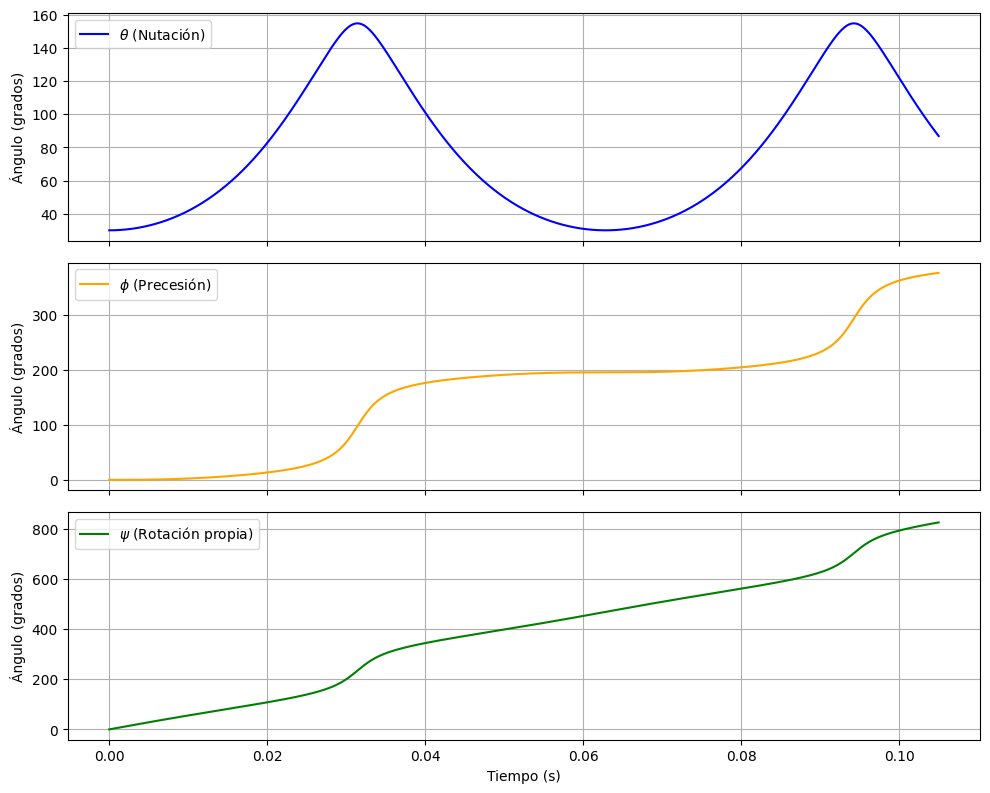

In [20]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Nutación (theta)
axs[0].plot(sol.t, np.degrees(sol.y[0]), label=r'$\theta$ (Nutación)', color='blue')
axs[0].set_ylabel('Ángulo (grados)')
axs[0].legend()
axs[0].grid(True)

# Precesión (phi)
axs[1].plot(sol.t, np.degrees(sol.y[1]), label=r'$\phi$ (Precesión)', color='orange')
axs[1].set_ylabel('Ángulo (grados)')
axs[1].legend()
axs[1].grid(True)

# Rotación propia (psi)
axs[2].plot(sol.t, np.degrees(sol.y[2]), label=r'$\psi$ (Rotación propia)', color='green')
axs[2].set_ylabel('Ángulo (grados)')
axs[2].set_xlabel('Tiempo (s)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

# Tarda en precesar 360 grados aproximadamente 0.105 segundos